# Phase 1 — RCM Data Discovery & Feasibility

This notebook tests an end-to-end, read-only RCM data path for a temporary inland-water Area of Interest (AOI) in Nova Scotia. It discovers official EODMS metadata, summarizes temporal coverage, reads a small window from one public RCM CEOS Analysis Ready Data (ARD) Cloud-Optimized GeoTIFF, and visualizes the result.

The feasibility snapshot ends on **2026-10-03**. This is not a change-detection workflow and does not select the final hackathon study area. No credentials are requested or stored, and no full satellite scene is downloaded.

## 1. Imports and configuration

In [11]:
from urllib.request import Request, urlopen

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from pyproj import Transformer
from pystac_client import Client
from rasterio.plot import plotting_extent
from rasterio.warp import transform_bounds
from rasterio.windows import from_bounds
from shapely.geometry import box

pd.set_option("display.max_colwidth", 100)

STAC_URL = "https://www.eodms-sgdot.nrcan-rncan.gc.ca/search"
ARD_COLLECTION = "rcm-ard"
LEVEL1_COLLECTION = "RCMImageProducts"
SEARCH_DATETIME = "2019-06-12T00:00:00Z/2026-10-03T23:59:59Z"

AOI_NAME = "Folly Lake, Colchester County, Nova Scotia"
AOI_BBOX = (-63.575, 45.515, -63.515, 45.565)  # west, south, east, north
AOI_CENTRE = (-63.546195, 45.538750)
SEARCH_CRS = "EPSG:4326"

print(f"AOI: {AOI_NAME}")
print(f"Search bbox ({SEARCH_CRS}): {AOI_BBOX}")
print(f"Search interval: {SEARCH_DATETIME}")

AOI: Folly Lake, Colchester County, Nova Scotia
Search bbox (EPSG:4326): (-63.575, 45.515, -63.515, 45.565)
Search interval: 2019-06-12T00:00:00Z/2026-10-03T23:59:59Z


## 2. AOI definition

Folly Lake is a temporary feasibility AOI. Nova Scotia's official lake inventory identifies it as an inland lake in Colchester County, and provincial documentation describes it as approximately 80 hectares. Its elongated water/land boundary is visible at the 20 m output spacing of the tested ARD asset. It is far from an ocean shoreline and the catalogue contains multiple acquisitions over the lake.

Search geometry uses longitude/latitude in EPSG:4326 (equivalent axis values to the API's CRS84 search coordinates).

,name,geometry
0,"Folly Lake, Colchester County, Nova Scotia","POLYGON ((-63.515 45.515, -63.515 45.565, -63.575 45.565, -63.575 45.515, -63.515 45.515))"


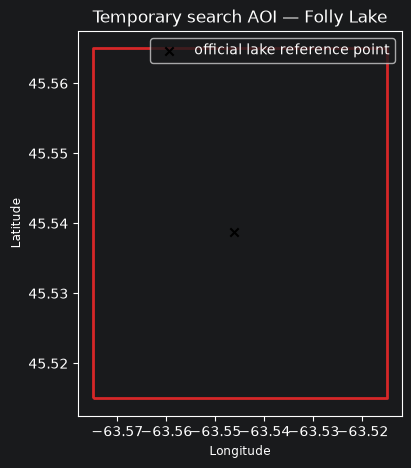

In [12]:
aoi = gpd.GeoDataFrame(
    {"name": [AOI_NAME]},
    geometry=[box(*AOI_BBOX)],
    crs=SEARCH_CRS,
)
display(aoi)

ax = aoi.boundary.plot(figsize=(7, 5), color="tab:red", linewidth=2)
ax.scatter(*AOI_CENTRE, color="black", marker="x", label="official lake reference point")
ax.set_title("Temporary search AOI — Folly Lake")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()
plt.show()

## 3. RCM collection discovery

Two official EODMS collections are useful for this feasibility check:

- `RCMImageProducts`: the broader Level-1 catalogue. Metadata and thumbnails can be searched publicly, while product ZIP delivery advertises bearer-token authentication.
- `rcm-ard`: CEOS Analysis Ready Data with public S3 assets suitable for direct windowed reads.

In [13]:
catalog = Client.open(STAC_URL)
collection_rows = []
for collection_id in (LEVEL1_COLLECTION, ARD_COLLECTION):
    collection = catalog.get_collection(collection_id)
    payload = collection.to_dict()
    collection_rows.append(
        {
            "id": collection.id,
            "title": collection.title,
            "license": payload.get("license"),
            "temporal_extent": payload.get("extent", {}).get("temporal", {}).get("interval"),
        }
    )
display(pd.DataFrame(collection_rows))

,id,title,license,temporal_extent
0,RCMImageProducts,RCMImageProducts,various,"[[2019-06-29T00:00:00Z, None]]"
1,rcm-ard,"RADARSAT Constellation Mission, CEOS-ARD",proprietary,"[[2019-06-12T00:00:00Z, 2048-01-01T00:00:00Z]]"


## 4. Search by AOI and date

The same AOI and date interval are used for both collections. The query fetches metadata only; it does not download Level-1 archives or full ARD rasters.

In [14]:
ard_items = list(
    catalog.search(
        collections=[ARD_COLLECTION], bbox=AOI_BBOX, datetime=SEARCH_DATETIME, max_items=None
    ).items()
)
level1_items = list(
    catalog.search(
        collections=[LEVEL1_COLLECTION], bbox=AOI_BBOX, datetime=SEARCH_DATETIME, max_items=5000
    ).items()
)

print(f"Public CEOS-ARD catalogue records: {len(ard_items):,}")
print(f"Level-1 catalogue product records: {len(level1_items):,}")
assert ard_items, "No public RCM-ARD records were found for the AOI."
assert level1_items, "No Level-1 RCM records were found for the AOI."

Public CEOS-ARD catalogue records: 10
Level-1 catalogue product records: 497


## 5. Metadata inspection

In [15]:
def platform_from_ard(item):
    title = item.properties.get("title", "")
    return title.split("_")[0] if title else None


ard_rows = []
for item in ard_items:
    props = item.properties
    platform = platform_from_ard(item)
    absolute_orbit = props.get("sat:absolute_orbit")
    ard_rows.append(
        {
            "item_id": item.id,
            "datetime": props.get("datetime"),
            "acquisition_key": f"{platform}-{absolute_orbit}",
            "platform": platform,
            "product_type": props.get("sar:product_type"),
            "instrument_mode": props.get("sar:instrument_mode"),
            "polarizations": ", ".join(props.get("sar:polarizations", [])),
            "orbit_state": props.get("sat:orbit_state"),
            "observation_direction": props.get("sar:observation_direction"),
            "processing_level": props.get("processing:level"),
            "grid_spacing_m": props.get("product_column_spacing"),
            "item_bbox": item.bbox,
            "asset_keys": ", ".join(item.assets),
        }
    )

ard_df = pd.DataFrame(ard_rows)
ard_df["datetime"] = pd.to_datetime(ard_df["datetime"], utc=True)
ard_df = ard_df.sort_values(["datetime", "item_id"]).reset_index(drop=True)
display(ard_df)

sample_item = min(ard_items, key=lambda item: item.properties["datetime"])
sample_properties = {
    key: sample_item.properties.get(key)
    for key in [
        "title", "datetime", "start_datetime", "end_datetime",
        "sar:instrument_mode", "sar:product_type", "sar:polarizations",
        "sat:orbit_state", "sat:absolute_orbit", "sat:relative_orbit",
        "processing:level", "ceosard:specification",
        "product_column_spacing", "product_row_spacing",
    ]
}
display(pd.Series(sample_properties, name="value").to_frame())

asset_rows = []
for key, asset in sample_item.assets.items():
    asset_rows.append(
        {
            "asset": key,
            "title": asset.title,
            "media_type": asset.media_type,
            "roles": ", ".join(asset.roles or []),
            "file_size_from_stac": asset.extra_fields.get("file:size"),
            "href": asset.href,
        }
    )
display(pd.DataFrame(asset_rows))

,item_id,datetime,acquisition_key,platform,product_type,instrument_mode,polarizations,orbit_state,observation_direction,processing_level,grid_spacing_m,item_bbox,asset_keys
0,41d2b89c-cd7a-496b-aaac-8d7326c70728,2025-07-14 10:32:20.611866+00:00,RCM3-33172.0,RCM3,MLC,Medium Resolution 30m,"CH, CV, XC",Descending,Right,l2,20.0,"[-65.012909, 45.242692, -63.243008, 45.994424]","rl, thumbnail, rr, metadata, local_contributing_area, rl_thumbnail, eula_license, rr_thumbnail, ..."
1,4a51a899-0b2d-41c6-9948-29d7c0dd8ffc,2025-07-26 10:32:24.612236+00:00,RCM3-33351.0,RCM3,MLC,Medium Resolution 30m,"CH, CV, XC",Descending,Right,l2,20.0,"[-65.013641, 45.242857, -63.301375, 45.797029]","eula_license, rr_thumbnail, rl_thumbnail, local_contributing_area, local_inc_angle, rr, gamma_to..."
2,8efbb31b-2951-4cb5-8d35-05121f1de930,2025-09-12 10:32:23.772101+00:00,RCM3-34067.0,RCM3,MLC,Medium Resolution 30m,"CH, CV, XC",Descending,Right,l2,20.0,"[-65.013434, 45.242992, -63.243523, 45.994722]","thumbnail, local_inc_angle, local_contributing_area, metadata, rr_thumbnail, rl_thumbnail, gamma..."
3,df8f9ed0-f8d6-4043-8ec0-be40128be006,2025-10-14 10:32:14.980643+00:00,RCM2-34544.0,RCM2,MLC,Medium Resolution 30m,"CH, CV, XC",Descending,Right,l2,20.0,"[-65.012932, 45.242469, -63.293356, 45.821498]","rr_thumbnail, rr, metadata, data_mask, gamma_to_sigma_ratio, local_contributing_area, thumbnail,..."
4,156a9cbb-70dc-4071-a663-d48150390185,2025-10-26 10:32:14.777394+00:00,RCM2-34723.0,RCM2,MLC,Medium Resolution 30m,"CH, CV, XC",Descending,Right,l2,20.0,"[-65.026387, 45.192986, -63.294043, 45.82158]","rl, eula_license, data_mask, rr_thumbnail, local_inc_angle, rr, metadata, rrrl, gamma_to_sigma_r..."
5,131e7580-fdb3-4897-b374-e4fc8330141c,2025-10-26 10:32:14.777396+00:00,RCM2-34723.0,RCM2,MLC,Medium Resolution 30m,"CH, CV, XC",Descending,Right,l2,20.0,"[-65.013792, 45.242403, -63.294274, 45.8216]","rr, gamma_to_sigma_ratio, thumbnail, rl, rrrl, local_contributing_area, metadata, rl_thumbnail, ..."
6,bc3da71c-0686-4254-921a-5f9ecbbc149a,2025-11-07 10:32:14.833284+00:00,RCM2-34902.0,RCM2,MLC,Medium Resolution 30m,"CH, CV, XC",Descending,Right,l2,20.0,"[-65.026417, 45.193025, -63.301143, 45.797005]","local_contributing_area, rr, metadata, rl, thumbnail, eula_license, data_mask, rl_thumbnail, rrr..."
7,73a52ca6-f8ac-4d82-a81b-08a23084460a,2025-11-07 10:32:14.833286+00:00,RCM2-34902.0,RCM2,MLC,Medium Resolution 30m,"CH, CV, XC",Descending,Right,l2,20.0,"[-65.013822, 45.242442, -63.301373, 45.797024]","thumbnail, rl_thumbnail, eula_license, rl, rr_thumbnail, rr, rrrl, local_inc_angle, data_mask, g..."
8,4b387ee1-5623-46e6-8001-811d4074986b,2026-07-05 10:31:59.373044+00:00,RCM2-38482.0,RCM2,MLC,Medium Resolution 30m,"CH, CV, XC",Descending,Right,l2,20.0,"[-63.786947, 45.206956, -61.767881, 46.702934]","rl_thumbnail, rr_thumbnail, thumbnail, local_inc_angle, eula_license, rr, gamma_to_sigma_ratio, ..."
9,d5d2c686-1c84-4304-83fd-4db5d9a9a8d8,2026-08-02 10:32:12.986710+00:00,RCM3-38900.0,RCM3,MLC,Medium Resolution 30m,"CH, CV, XC",Descending,Right,l2,20.0,"[-63.783639, 45.218918, -61.764411, 46.714863]","gamma_to_sigma_ratio, rrrl, data_mask, eula_license, rr_thumbnail, local_contributing_area, rr, ..."


,value
title,RCM3_OK3555381_PK3698787_1_SC30MCPB_20250714_103217_CH_CV_MLC
datetime,2025-07-14T10:32:20.611866
start_datetime,2025-07-14T10:32:20.611866
end_datetime,2025-07-14T10:32:29.340963
sar:instrument_mode,Medium Resolution 30m
sar:product_type,MLC
sar:polarizations,"[CH, CV, XC]"
sat:orbit_state,Descending
sat:absolute_orbit,33172.0
sat:relative_orbit,37


,asset,title,media_type,roles,file_size_from_stac,href
0,rl,Backscatter Measurements RL Polarization,image/tiff; application=geotiff; profile=cloud-optimized,"data, gamma()",None,https://rcm-ceos-ard.s3.ca-central-1.amazonaws.com/MLC/2025/07/14/RCM3_OK3555381_PK3698787_1_SC3...
1,thumbnail,Thumbnail,image/png,thumbnail,None,https://rcm-ceos-ard.s3.ca-central-1.amazonaws.com/MLC/2025/07/14/RCM3_OK3555381_PK3698787_1_SC3...
2,rr,Backscatter Measurements RR Polarization,image/tiff; application=geotiff; profile=cloud-optimized,"data, gamma()",None,https://rcm-ceos-ard.s3.ca-central-1.amazonaws.com/MLC/2025/07/14/RCM3_OK3555381_PK3698787_1_SC3...
3,metadata,ARD Product Metadata,text/xml,metadata,None,https://rcm-ceos-ard.s3.ca-central-1.amazonaws.com/MLC/2025/07/14/RCM3_OK3555381_PK3698787_1_SC3...
4,local_contributing_area,Scattering Area Image,image/tiff; application=geotiff; profile=cloud-optimized,data,None,https://rcm-ceos-ard.s3.ca-central-1.amazonaws.com/MLC/2025/07/14/RCM3_OK3555381_PK3698787_1_SC3...
5,rl_thumbnail,Backscatter RL Polarization Quicklook,image/tiff; application=geotiff,,None,https://rcm-ceos-ard.s3.ca-central-1.amazonaws.com/MLC/2025/07/14/RCM3_OK3555381_PK3698787_1_SC3...
6,eula_license,EULA,application/pdf,license,None,https://rcm-ceos-ard.s3.ca-central-1.amazonaws.com/MLC/2025/07/14/RCM3_OK3555381_PK3698787_1_SC3...
7,rr_thumbnail,Backscatter RR Polarization Quicklook,image/tiff; application=geotiff,,None,https://rcm-ceos-ard.s3.ca-central-1.amazonaws.com/MLC/2025/07/14/RCM3_OK3555381_PK3698787_1_SC3...
8,local_inc_angle,Local Incident Angle Image,image/tiff; application=geotiff; profile=cloud-optimized,"data, local-incidence-angle",None,https://rcm-ceos-ard.s3.ca-central-1.amazonaws.com/MLC/2025/07/14/RCM3_OK3555381_PK3698787_1_SC3...
9,rrrl,Normalized Polarimetric Radar Covariance Matrix (CovMat),image/tiff; application=geotiff; profile=cloud-optimized,"data, covmat",None,https://rcm-ceos-ard.s3.ca-central-1.amazonaws.com/MLC/2025/07/14/RCM3_OK3555381_PK3698787_1_SC3...


## 6. Temporal coverage and observations per year

Multiple catalogue records can represent the same overpass. ARD records are grouped by the satellite identifier parsed from the product title plus `sat:absolute_orbit`. Level-1 records are grouped by `satellite_id` plus `absolute_orbit`. These are approximate unique orbit passes, not proof that every pass has identical geometry or processing.

,collection,catalogue_records,approx_unique_orbit_passes,earliest,latest
0,rcm-ard,10,8,2025-07-14 10:32:20.611866+00:00,2026-08-02 10:32:12.986710+00:00
1,RCMImageProducts,497,356,2020-01-02 10:31:33.238000+00:00,2026-09-11 10:32:06.256000+00:00


,level1_passes,public_ard_passes
year,,
2020,20,0
2021,57,0
2022,81,0
2023,86,0
2024,63,0
2025,32,6
2026,17,2


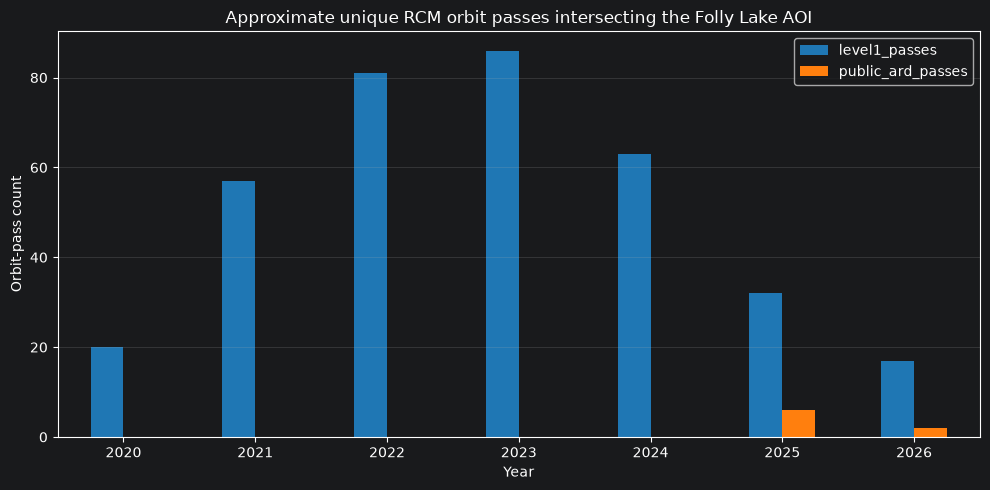

In [16]:
ard_passes = ard_df.sort_values("datetime").drop_duplicates("acquisition_key").reset_index(drop=True)

level1_rows = []
for item in level1_items:
    props = item.properties
    platform = props.get("satellite_id")
    absolute_orbit = props.get("absolute_orbit")
    level1_rows.append(
        {
            "item_id": item.id,
            "datetime": props.get("datetime"),
            "pass_key": f"{platform}-{absolute_orbit}",
            "platform": platform,
            "product_type": props.get("product:type"),
            "instrument_mode": props.get("sar:instrument_mode"),
            "polarizations": ", ".join(props.get("sar:polarizations", [])),
            "orbit_state": props.get("sat:orbit_state"),
            "product_format": props.get("product_format"),
            "size_mb": props.get("megabytes"),
        }
    )

level1_df = pd.DataFrame(level1_rows)
level1_df["datetime"] = pd.to_datetime(level1_df["datetime"], utc=True)
level1_df = level1_df.sort_values(["datetime", "item_id"]).reset_index(drop=True)
level1_passes = level1_df.sort_values("datetime").drop_duplicates("pass_key").reset_index(drop=True)

coverage_summary = pd.DataFrame(
    [
        {"collection": ARD_COLLECTION, "catalogue_records": len(ard_df),
         "approx_unique_orbit_passes": len(ard_passes), "earliest": ard_passes["datetime"].min(),
         "latest": ard_passes["datetime"].max()},
        {"collection": LEVEL1_COLLECTION, "catalogue_records": len(level1_df),
         "approx_unique_orbit_passes": len(level1_passes), "earliest": level1_passes["datetime"].min(),
         "latest": level1_passes["datetime"].max()},
    ]
)
display(coverage_summary)

ard_years = ard_passes.groupby(ard_passes["datetime"].dt.year).size().rename("public_ard_passes")
level1_years = level1_passes.groupby(level1_passes["datetime"].dt.year).size().rename("level1_passes")
yearly = pd.concat([level1_years, ard_years], axis=1).fillna(0).astype(int)
yearly.index.name = "year"
display(yearly)

ax = yearly.plot.bar(figsize=(10, 5), color=["tab:blue", "tab:orange"])
ax.set_title("Approximate unique RCM orbit passes intersecting the Folly Lake AOI")
ax.set_xlabel("Year")
ax.set_ylabel("Orbit-pass count")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Acquisition frequency and obvious gaps

In [17]:
def interval_table(passes):
    times = passes["datetime"].sort_values().reset_index(drop=True)
    return pd.DataFrame(
        {"previous_acquisition": times.shift(1), "acquisition": times,
         "gap_days": times.diff().dt.total_seconds() / 86_400}
    ).dropna()


ard_intervals = interval_table(ard_passes)
level1_intervals = interval_table(level1_passes)
display(ard_intervals)

frequency_summary = pd.DataFrame(
    [
        {"collection": ARD_COLLECTION, "median_gap_days": ard_intervals["gap_days"].median(),
         "minimum_gap_days": ard_intervals["gap_days"].min(), "maximum_gap_days": ard_intervals["gap_days"].max()},
        {"collection": LEVEL1_COLLECTION, "median_gap_days": level1_intervals["gap_days"].median(),
         "minimum_gap_days": level1_intervals["gap_days"].min(), "maximum_gap_days": level1_intervals["gap_days"].max()},
    ]
)
display(frequency_summary.round(2))
print("The public ARD subset is irregular and contains a gap of about 240 days.")
print("The broader Level-1 archive is much denser, but also has gaps and mixed acquisition modes.")

,previous_acquisition,acquisition,gap_days
1,2025-07-14 10:32:20.611866+00:00,2025-07-26 10:32:24.612236+00:00,12.000046
2,2025-07-26 10:32:24.612236+00:00,2025-09-12 10:32:23.772101+00:00,47.999990
3,2025-09-12 10:32:23.772101+00:00,2025-10-14 10:32:14.980643+00:00,31.999898
4,2025-10-14 10:32:14.980643+00:00,2025-10-26 10:32:14.777394+00:00,11.999998
5,2025-10-26 10:32:14.777394+00:00,2025-11-07 10:32:14.833284+00:00,12.000001
6,2025-11-07 10:32:14.833284+00:00,2026-07-05 10:31:59.373044+00:00,239.999821
7,2026-07-05 10:31:59.373044+00:00,2026-08-02 10:32:12.986710+00:00,28.000158


,collection,median_gap_days,minimum_gap_days,maximum_gap_days
0,rcm-ard,28.0,12.00,240.0
1,RCMImageProducts,4.0,0.47,140.0


The public ARD subset is irregular and contains a gap of about 240 days.
The broader Level-1 archive is much denser, but also has gaps and mixed acquisition modes.


## 8. Product, polarization, resolution, and access inspection

In [18]:
ard_characteristics = pd.Series(
    {
        "product_types": sorted(ard_df["product_type"].dropna().unique()),
        "instrument_modes": sorted(ard_df["instrument_mode"].dropna().unique()),
        "polarization_sets": sorted(ard_df["polarizations"].dropna().unique()),
        "orbit_states": sorted(ard_df["orbit_state"].dropna().unique()),
        "processing_levels": sorted(ard_df["processing_level"].dropna().unique()),
        "output_grid_spacing_m": sorted(ard_df["grid_spacing_m"].dropna().unique()),
    }, name="confirmed_values"
)
display(ard_characteristics.to_frame())

display(level1_df["product_type"].value_counts().rename("record_count").to_frame())
level1_access = level1_items[0].assets.get("product")
print("Level-1 product asset media type:", level1_access.media_type)
print("Level-1 product auth reference:", level1_access.extra_fields.get("auth:refs"))
print("Level-1 thumbnails are public; product ZIP delivery requires an EODMS bearer token.")

rr_href = sample_item.assets["rr"].href
try:
    request = Request(rr_href, method="HEAD")
    with urlopen(request, timeout=30) as response:
        rr_size_bytes = int(response.headers.get("Content-Length"))
        accepts_ranges = response.headers.get("Accept-Ranges")
    print(f"Selected RR COG size: {rr_size_bytes:,} bytes ({rr_size_bytes / 1024**2:.2f} MiB)")
    print("HTTP range support:", accepts_ranges)
except Exception as exc:
    rr_size_bytes = None
    print("HTTP file size was not available during this run:", exc)

,confirmed_values
product_types,[MLC]
instrument_modes,[Medium Resolution 30m]
polarization_sets,"[CH, CV, XC]"
orbit_states,[Descending]
processing_levels,[l2]
output_grid_spacing_m,[20.0]


,record_count
product_type,
GRD,295
MLC,146
SLC,56


Level-1 product asset media type: application/zip
Level-1 product auth reference: ['bearer']
Level-1 thumbnails are public; product ZIP delivery requires an EODMS bearer token.
Selected RR COG size: 74,809,647 bytes (71.34 MiB)
HTTP range support: bytes


## 9. Load one usable RCM-ARD raster

The earliest public ARD item is used. Rasterio opens the public RR Cloud-Optimized GeoTIFF over HTTPS and reads only the Folly Lake window using byte-range requests. The full scene is not saved locally.

In [19]:
selected_item = min(ard_items, key=lambda item: item.properties["datetime"])
selected_asset = selected_item.assets["rr"]

with rasterio.Env(GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR", CPL_VSIL_CURL_ALLOWED_EXTENSIONS=".tif"):
    with rasterio.open(selected_asset.href) as src:
        native_bounds = transform_bounds(SEARCH_CRS, src.crs, *AOI_BBOX, densify_pts=21)
        read_window = from_bounds(*native_bounds, transform=src.transform).round_offsets().round_lengths()
        rr = src.read(1, window=read_window, masked=True)
        window_transform = src.window_transform(read_window)
        image_extent = plotting_extent(rr, window_transform)
        raster_metadata = {
            "item_id": selected_item.id,
            "acquisition_datetime": selected_item.properties.get("datetime"),
            "asset": "rr",
            "asset_media_type": selected_asset.media_type,
            "driver": src.driver,
            "crs": str(src.crs),
            "pixel_size": src.res,
            "full_raster_shape": (src.height, src.width),
            "window_shape": rr.shape,
            "valid_pixels": int(rr.count()),
            "nodata": src.nodata,
            "overviews": src.overviews(1),
        }
        loaded_crs = src.crs

display(pd.Series(raster_metadata, name="value").to_frame())
assert rr.count() > 0, "The selected AOI window contains no valid pixels."

,value
item_id,41d2b89c-cd7a-496b-aaac-8d7326c70728
acquisition_datetime,2025-07-14T10:32:20.611866
asset,rr
asset_media_type,image/tiff; application=geotiff; profile=cloud-optimized
driver,GTiff
crs,EPSG:32620
pixel_size,"(20.0, 20.0)"
full_raster_shape,"(4608, 7168)"
window_shape,"(279, 236)"
valid_pixels,65844


## 10. Basic visualization

RR backscatter is converted to decibels only for display. Percentile stretching improves contrast. This is a visual feasibility check, not a water classifier or thresholding method.

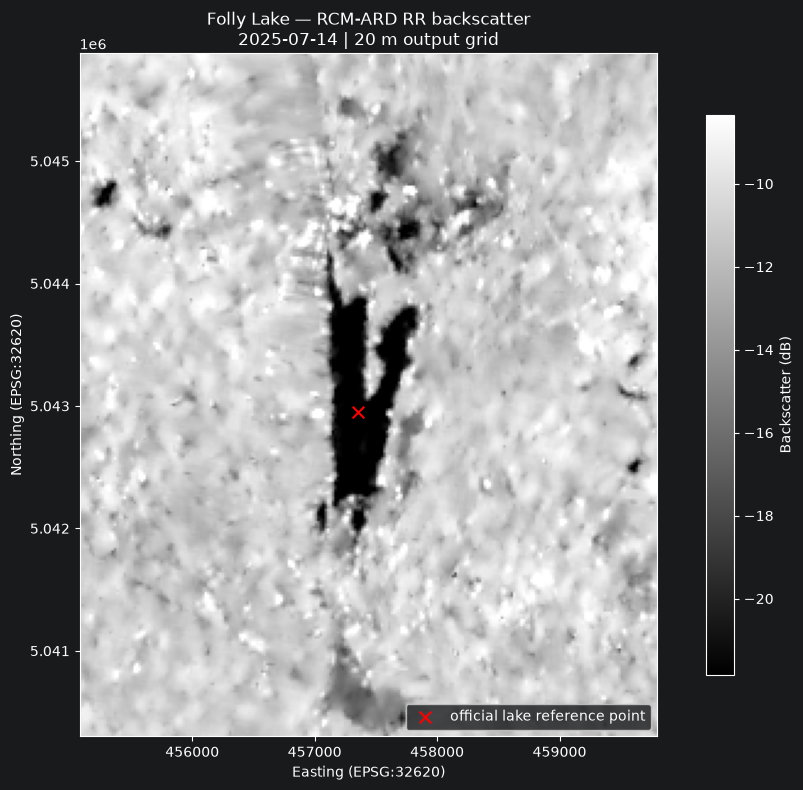

Display range: -21.84 to -8.34 dB
Visual check: the lake is dark relative to much of the surrounding land, and the shoreline is distinguishable.


In [20]:
rr_db = np.ma.masked_invalid(10 * np.log10(np.clip(rr.filled(np.nan), 1e-8, None)))
display_min, display_max = np.percentile(rr_db.compressed(), [2, 98])
centre_transformer = Transformer.from_crs(SEARCH_CRS, loaded_crs, always_xy=True)
centre_x, centre_y = centre_transformer.transform(*AOI_CENTRE)

fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(rr_db, cmap="gray", vmin=display_min, vmax=display_max, extent=image_extent)
ax.scatter(centre_x, centre_y, color="red", marker="x", s=70, label="official lake reference point")
ax.set_title("Folly Lake — RCM-ARD RR backscatter\n" + f"{selected_item.properties['datetime'][:10]} | 20 m output grid")
ax.set_xlabel(f"Easting ({loaded_crs})")
ax.set_ylabel(f"Northing ({loaded_crs})")
ax.legend(loc="lower right")
fig.colorbar(image, ax=ax, label="Backscatter (dB)", shrink=0.82)
plt.tight_layout()
plt.show()

print(f"Display range: {display_min:.2f} to {display_max:.2f} dB")
print("Visual check: the lake is dark relative to much of the surrounding land, and the shoreline is distinguishable.")

## 11. Findings

Snapshot confirmed on 2026-10-03:

- **AOI:** Folly Lake, Colchester County, Nova Scotia; bbox `(-63.575, 45.515, -63.515, 45.565)` in EPSG:4326.
- **Full Level-1 catalogue:** 497 product records grouped into 356 approximate satellite/orbit passes from 2020-01-02 through 2026-09-11. Median pass gap is about 4 days, with a maximum observed gap of about 140 days. Product records include GRD, SLC, and MLC configurations.
- **Public CEOS-ARD subset:** 10 records grouped into 8 satellite/orbit passes from 2025-07-14 through 2026-08-02. Observed gaps are 12, 48, 32, 12, 12, 240, and 28 days; the median is about 28 days.
- **Tested ARD product:** Level-2 MLC, CEOS ARD NRB-POL, `Medium Resolution 30m`, descending orbit, with CH/CV/XC listed in STAC metadata and RR/RL public raster assets.
- **Raster:** the selected RR asset is a Cloud-Optimized GeoTIFF. It opens as EPSG:32620 with a 20 m output grid. The 2025-07-14 file reports 74,809,647 bytes over HTTP, but only the small AOI window is read.
- **Visual result:** Folly Lake is dark relative to much of the surrounding land and its shoreline is readily inspectable. This is qualitative only; no classification threshold has been selected.
- **Access:** public `rcm-ard` S3 assets were read without credentials. Level-1 product ZIP assets in `RCMImageProducts` declare bearer-token authentication, so an EODMS account/token would be required only if a later phase needs those downloads.

## 12. Open questions / next steps

1. Determine why the public CEOS-ARD subset is much smaller and less regular than the searchable Level-1 archive for this AOI.
2. Confirm whether all eight public ARD passes have comparable geometry and processing inputs before any multi-temporal comparison.
3. Review the item EULA and EODMS access terms before redistributing derived products.
4. Decide whether Folly Lake remains useful after the final environmental phenomenon and study area are selected.
5. In the next phase, inspect multiple ARD dates and design preprocessing checks; do not begin change detection until alignment and comparability are validated.

## Scope note for the final case study

Folly Lake is a temporary feasibility AOI used to test public RCM access and inspect available assets. It is not the final Lower Fraser study area, does not define the event-change result, and contributes no flood-area estimate to the final case.
